# 1. CV analysis

In [2]:
import importlib
import os
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
importlib.reload(config)
from viz_style import apply_style
apply_style()

CV = Path('./CV_Results_mixed')
ENG = Path('./engine_state_mixed')
FIG = CV / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)

# Reference values a correctly-specified normative model must hit on held-out HC (a true null).
TARGET = {'mean_z': 0.0, 'std_z': 1.0, 'exceed': 0.05, 'med_z2': 0.4549}  # med_z2 = median of chi2(df=1)

NZ_BINS = [30, 40, 50, 60, 80, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 676]
NZ_LABELS = [
    f'{NZ_BINS[i]+1}={NZ_BINS[i+1]}' for i in range(0, len(NZ_BINS)-1)
]

In [3]:
# 0. Load CV artifacts
fold = pd.read_csv(CV / 'fold_stats.csv')
pool_fold = pd.read_csv(CV / 'pool_fold_stats.csv')
cv = pd.read_csv(CV / 'cv_stats.csv')
train = pd.read_csv(ENG / 'training_summary.csv')

# per-gene fold stability: a gene is "stable" only if the individual GLMM converged in all 5 folds
stab = fold.groupby('gene')['ok'].sum().rename('n_fold_ok').reset_index()
cv = cv.merge(stab, on='gene', how='left')
cv['stable'] = cv['n_fold_ok'] == config.SPIKE_PARAMS['n_splits']
cv['nz_bin'] = pd.cut(cv['nz'], bins=NZ_BINS, labels=NZ_LABELS)
cv['route_stage'] = cv['route'] + '/' + cv['stage']

print(f"engine ok genes: {int(train['ok'].sum())} | cv_stats rows: {len(cv)} "
      f"(missing {int(train['ok'].sum()) - len(cv)}: all folds failed)")
print(f"model route: {int((cv.route == 'model').sum())} | pool route: {int((cv.route == 'pool').sum())}")
print(f"\npool-route fold fits (one shared GLMM per fold):\n{pool_fold.to_string(index=False)}")
display(cv.groupby('route_stage').agg(
    n=('gene', 'size'), nz_med=('nz', 'median'), mean_z=('mean_z', 'mean'), std_z=('std_z', 'mean'),
    exceed=('cv_naive_exceed', 'mean'), stable=('stable', 'mean')).round(4))

engine ok genes: 19858 | cv_stats rows: 19858 (missing 0: all folds failed)
model route: 17798 | pool route: 2060

pool-route fold fits (one shared GLMM per fold):
 fold   ok family  fail_reason
    0 True negbin          NaN
    1 True negbin          NaN
    2 True negbin          NaN
    3 True negbin          NaN
    4 True negbin          NaN


,n,nz_med,mean_z,std_z,exceed,stable
route_stage,,,,,,
model/nbi_full_eb,17752,564.0,0.0060,1.0200,0.0544,0.9838
model/nbi_intercept_eb,46,46.5,0.0293,1.0042,0.0487,0.1739
pool/pool,2060,13.0,-0.0008,0.9484,0.0395,0.0000


model-route fold success: 0.9949 (88535/88990)
genes converging in all 5 folds: 0.9817

train-stage routing (deployed engine):
route     stage           
excluded  nbi_intercept_eb      239
model     nbi_full_eb         17752
          nbi_intercept_eb       46
pool      pool                 2060

fold fail_reason:
fail_reason
not_converged_or_explosion_or_tau2_bound    455


,n_gene,fold_ok,all5_ok
nz_bin,,,
31=40,412,0.9277,0.7476
41=50,354,0.9514,0.8305
51=60,354,0.9616,0.8701
61=80,604,0.9801,0.9255
81=100,522,0.9870,0.9521
101=150,991,0.9952,0.9798
151=200,799,0.9950,0.9812
201=250,628,0.9978,0.9920
251=300,554,0.9986,0.9946


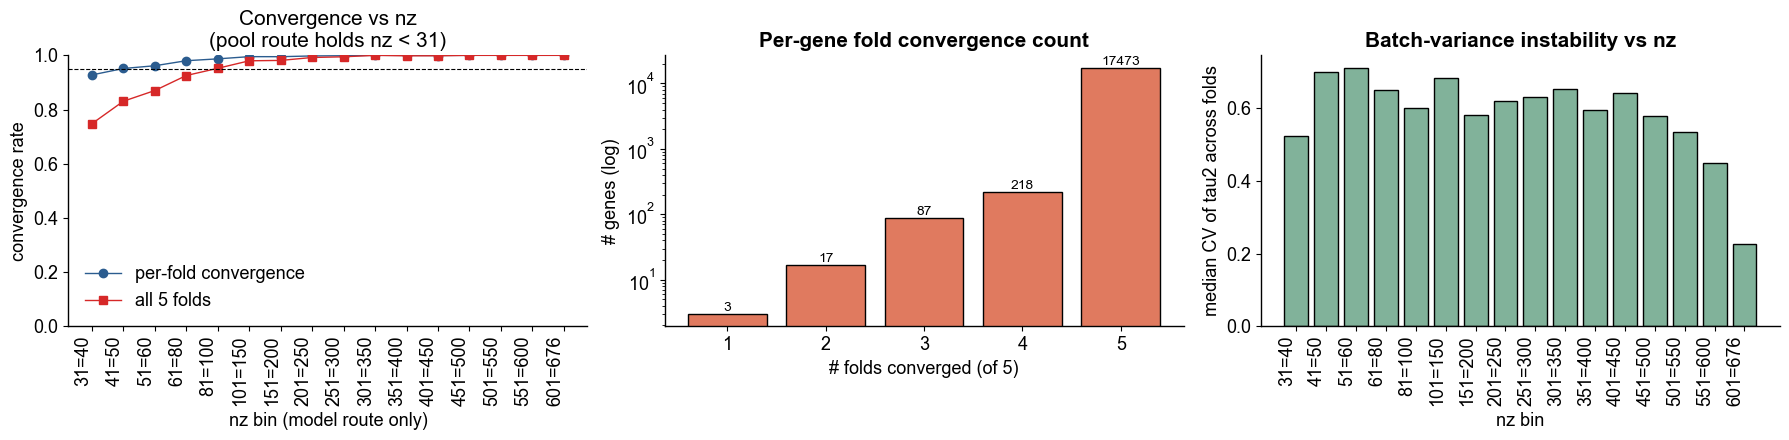

In [4]:
fold_nz = fold.merge(train[['gene', 'nz']], on='gene')
fold_nz['nz_bin'] = pd.cut(fold_nz['nz'], bins=NZ_BINS, labels=NZ_LABELS)
by_nz = fold_nz.groupby('nz_bin', observed=True).agg(n_gene=('gene', 'nunique'), fold_ok=('ok', 'mean'))
by_nz['all5_ok'] = cv[cv.route == 'model'].groupby('nz_bin', observed=True)['stable'].mean()

print(f"model-route fold success: {fold['ok'].mean():.4f} ({int(fold['ok'].sum())}/{len(fold)})")
print(f"genes converging in all 5 folds: {cv.loc[cv.route == 'model', 'stable'].mean():.4f}")
print(f"\ntrain-stage routing (deployed engine):\n"
      f"{train.groupby(['route', 'stage'], dropna=False).size().to_string()}")
print(f"\nfold fail_reason:\n{fold.loc[~fold['ok'], 'fail_reason'].fillna('(blank)').value_counts().to_string()}")
display(by_nz.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
x = np.arange(len(by_nz))
axes[0].plot(x, by_nz['fold_ok'], marker='o', color='#2b5c8f', label='per-fold convergence')
axes[0].plot(x, by_nz['all5_ok'], marker='s', color='#d62828', label='all 5 folds')
axes[0].axhline(0.95, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x); axes[0].set_xticklabels(by_nz.index, rotation=90, ha='right')
axes[0].set_ylabel('convergence rate'); axes[0].set_xlabel('nz bin (model route only)')
axes[0].set_title(f'Convergence vs nz\n(pool route holds nz < {config.NZ_A_MAX})')
axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False)

nfold = cv.loc[cv.route == 'model', 'n_fold_ok'].value_counts().sort_index()
axes[1].bar(nfold.index.astype(int), nfold.values, color='#e07a5f', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_xlabel('# folds converged (of 5)'); axes[1].set_ylabel('# genes (log)')
axes[1].set_title('Per-gene fold convergence count',fontweight='bold')
for i, v in zip(nfold.index.astype(int), nfold.values):
    axes[1].text(i, v, str(int(v)), ha='center', va='bottom') 

# tau2 is refit per fold; its spread across folds is a second, continuous stability read-out that
# does not depend on the binary convergence flag.
t2 = fold_nz[fold_nz['ok']].groupby('gene').agg(tau2_cv=('tau2', lambda v: v.std() / max(v.mean(), 1e-9)),
                                                nz=('nz', 'first'))
t2['nz_bin'] = pd.cut(t2['nz'], bins=NZ_BINS, labels=NZ_LABELS)
med = t2.groupby('nz_bin', observed=True)['tau2_cv'].median()
axes[2].bar(np.arange(len(med)), med.values, color='#81b29a', edgecolor='black')
axes[2].set_xticks(np.arange(len(med))); axes[2].set_xticklabels(med.index, rotation=90, ha='right')
axes[2].set_ylabel('median CV of tau2 across folds'); axes[2].set_xlabel('nz bin')
axes[2].set_title('Batch-variance instability vs nz',fontweight='bold')

plt.tight_layout(); plt.savefig(FIG / 'cv_convergence.png', dpi=150, bbox_inches='tight'); plt.show()

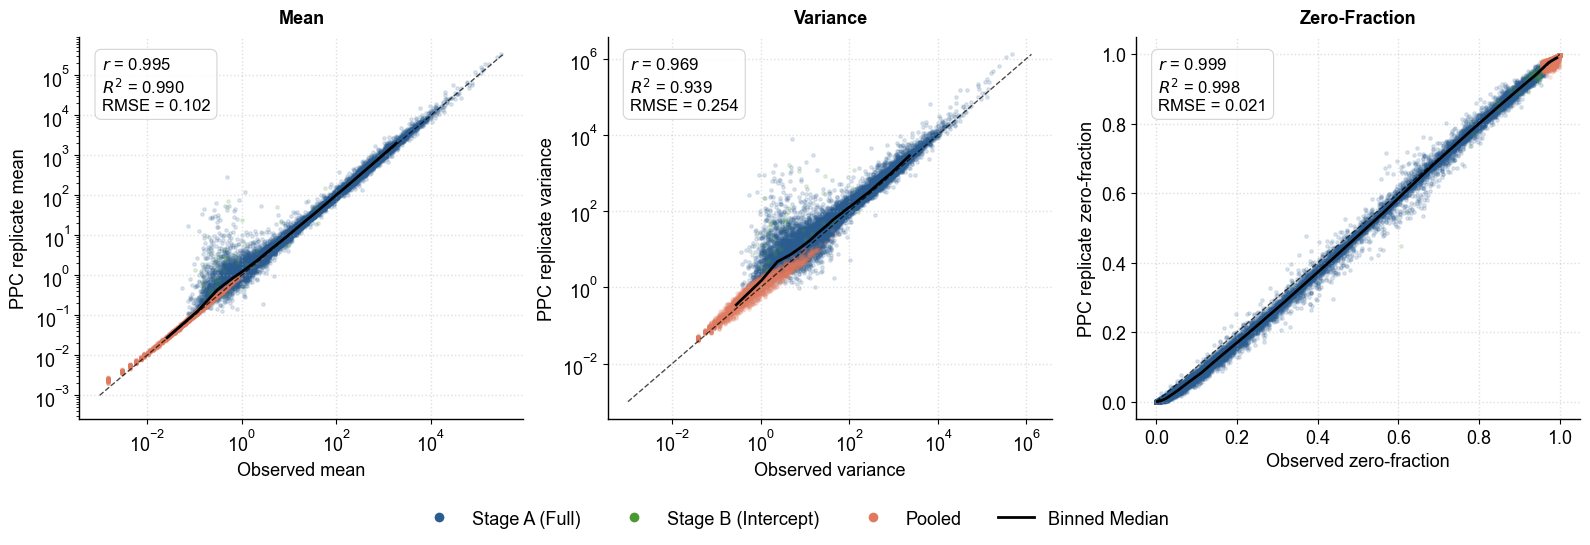

held-out calibration, CV-based PPC replicates (log10 scale for mean/var, linear for zero):
  Mean           (all)   : r=0.9952  R2=0.9905  RMSE=0.1018  n=19858
  Mean           (Stage A (Full)    ): r=0.9944  R2=0.9887  RMSE=0.1046  n=17752
  Mean           (Stage B (Intercept)): r=0.6859  R2=0.4705  RMSE=0.5021  n=46
  Mean           (Pooled            ): r=0.9987  R2=0.9973  RMSE=0.0030  n=2060
  Variance       (all)   : r=0.9691  R2=0.9391  RMSE=0.2541  n=19858
  Variance       (Stage A (Full)    ): r=0.9585  R2=0.9188  RMSE=0.2626  n=17752
  Variance       (Stage B (Intercept)): r=0.5771  R2=0.3331  RMSE=0.9785  n=46
  Variance       (Pooled            ): r=0.9615  R2=0.9245  RMSE=0.0823  n=2060
  Zero-Fraction  (all)   : r=0.9992  R2=0.9984  RMSE=0.0208  n=19858
  Zero-Fraction  (Stage A (Full)    ): r=0.9989  R2=0.9979  RMSE=0.0217  n=17752
  Zero-Fraction  (Stage B (Intercept)): r=0.9775  R2=0.9556  RMSE=0.0300  n=46
  Zero-Fraction  (Pooled            ): r=0.7688  R2=0.5910  RM

In [14]:
from MixedEffectsModeling.validation.ppc_simulate import simulate_marginal_nb
from matplotlib.lines import Line2D

PPC_N_REPS = 200
CAL_CACHE = CV / 'cv_calibration_moments.csv'

if CAL_CACHE.exists():
    cal = pd.read_csv(CAL_CACHE)
else:
    ppcd = pickle.load(open(CV / 'cv_ppc.pkl', 'rb'))
    rows = []
    for i, (g, d) in enumerate(ppcd.items()):
        y = np.asarray(d['y'], float)
        mu = np.asarray(d['mu'], float)
        alpha = np.asarray(d['alpha'], float)
        tau2 = np.asarray(d['tau2'], float)
        if y.size == 0 or not (np.isfinite(mu).all() and np.isfinite(alpha).all() and np.isfinite(tau2).all()):
            continue
        y_rep = simulate_marginal_nb(mu, alpha, tau2, PPC_N_REPS, seed=1000 + i)
        rows.append({
            'gene': g, 
            'obs_mean': y.mean(), 
            'pred_mean': y_rep.mean(1).mean(),
            'obs_var': y.std(), 
            'pred_var': y_rep.std(1).mean(),
            'obs_zero': (y == 0).mean(), 
            'pred_zero': (y_rep == 0).mean(1).mean()
        })
    cal = pd.DataFrame(rows)
    cal.to_csv(CAL_CACHE, index=False)

cal = cal.merge(cv[['gene', 'route', 'stage']], on='gene', how='left')

STAGE_MAP = {
    'nbi_full_eb': ('Stage A (Full)', '#2b5c8f'),
    'nbi_intercept_eb': ('Stage B (Intercept)', '#499831'),
    'pool': ('Pooled', '#e07a5f')
}

def calib_stats(o, p, logscale):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p)
    o, p = o[m], p[m]
    if logscale:
        o, p = np.log10(o + 1), np.log10(p + 1)
    r = np.corrcoef(o, p)[0, 1]
    return r, r ** 2, np.sqrt(np.mean((p - o) ** 2)), len(o)

def binned(o, p, nb=20):
    o, p = np.asarray(o, float), np.asarray(p, float)
    m = np.isfinite(o) & np.isfinite(p) & (o > 0)
    o, p = o[m], p[m]
    q = np.unique(np.quantile(o, np.linspace(0, 1, nb + 1)))
    idx = np.clip(np.digitize(o, q[1:-1]), 0, len(q) - 2)
    return (np.array([np.median(o[idx == k]) for k in range(len(q) - 1)]),
            np.array([np.median(p[idx == k]) for k in range(len(q) - 1)]))

panels = [
    ('obs_mean', 'pred_mean', 'Mean', True),
    ('obs_var', 'pred_var', 'Variance', True),
    ('obs_zero', 'pred_zero', 'Zero-Fraction', False)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (oc, pc, title_str, logsc) in zip(axes, panels):
    for stage_key, (label_name, color) in STAGE_MAP.items():
        s = cal[cal.stage == stage_key]
        ax.scatter(s[oc], s[pc], s=6, alpha=0.15, color=color)
    
    bx, by = binned(cal[oc], cal[pc])
    ax.plot(bx, by, '-', color='black', linewidth=2)
    
    if logsc:
        lo = max(min(cal[oc].min(), cal[pc].min()), 1e-3)
        hi = max(cal[oc].max(), cal[pc].max())
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.7)
        ax.set_xscale('log')
        ax.set_yscale('log')
    else:
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)
        
    r, r2, rmse, n = calib_stats(cal[oc], cal[pc], logsc)
    
    ax.set_title(title_str, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(f'Observed {title_str.lower()}')
    ax.set_ylabel(f'PPC replicate {title_str.lower()}')
    
    stats_text = f"$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}"
    bbox_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc', linewidth=0.8)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', bbox=bbox_props)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.4)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2b5c8f', markersize=8, label='Stage A (Full)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#499831', markersize=8, label='Stage B (Intercept)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e07a5f', markersize=8, label='Pooled'),
    Line2D([0], [0], color='black', lw=2, label='Binned Median')
]

fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(FIG / 'cv_ppc_replicates.png', dpi=300, bbox_inches='tight')
plt.show()

print('held-out calibration, CV-based PPC replicates (log10 scale for mean/var, linear for zero):')
for oc, pc, lab, logsc in panels:
    r, r2, rmse, n = calib_stats(cal[oc], cal[pc], logsc)
    print(f'  {lab:14s} (all)   : r={r:.4f}  R2={r2:.4f}  RMSE={rmse:.4f}  n={n}')
    for stage_key, (label_name, _) in STAGE_MAP.items():
        sub = cal[cal.stage == stage_key]
        r, r2, rmse, n = calib_stats(sub[oc], sub[pc], logsc)
        print(f'  {lab:14s} ({label_name:18s}): r={r:.4f}  R2={r2:.4f}  RMSE={rmse:.4f}  n={n}')

In [ ]:
from scipy.stats import kurtosis, norm, skew

from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.core.shash import fit_shash, shash_transform_to_z

SHASH_NESTED_PATH = CV / 'cv_gene_shash_nested.csv'
N_SHASH_FOLDS = 5
Q_LEVELS = (0.05, 0.01)

if SHASH_NESTED_PATH.exists():
    shn = pd.read_csv(SHASH_NESTED_PATH)
else:
    zdict = pickle.load(open(CV / 'cv_zscores.pkl', 'rb'))
    # production SHASH: per-fold train-fit (cv_engine.py fits SHASH on each fold's TRAIN Z only,
    # applies it to that fold's held-out Z) -- NOT a single self-fit on the pooled held-out Z, which
    # is the leaky pattern this cell used to run (cv_stats.csv no longer carries a single cv_shash_*
    # per gene for exactly that reason).
    zdict_prod = pickle.load(open(CV / 'cv_zscores_shash.pkl', 'rb'))
    rng = np.random.default_rng(42)
    rows = []
    for g, z in zdict.items():
        finite = np.isfinite(z)
        z = z[finite].astype(np.float64)
        if len(z) < 20 or g not in zdict_prod:
            continue
        row = {'gene': g, 'n_valid': len(z)}

        pv_raw = 2 * norm.sf(np.abs(z))
        for q in Q_LEVELS:
            row[f'raw_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_raw, q=q).sum())

        z_prod = zdict_prod[g][finite]
        row['ins_mean'] = float(np.mean(z_prod)); row['ins_std'] = float(np.std(z_prod))
        row['ins_skew'] = float(skew(z_prod)); row['ins_kurt'] = float(kurtosis(z_prod))
        pv_prod = 2 * norm.sf(np.abs(z_prod))
        for q in Q_LEVELS:
            row[f'ins_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_prod, q=q).sum())

        # independent double-check: a SECOND, in-notebook nested split of the pooled held-out Z
        # itself (unrelated to cv_engine's own fold split) -- should roughly agree with z_prod above
        # if the per-fold production correction generalizes.
        idx = rng.permutation(len(z))
        folds = np.array_split(idx, N_SHASH_FOLDS)
        z_nested = z.copy()
        for k in range(N_SHASH_FOLDS):
            test_idx = folds[k]
            train_idx = np.concatenate([folds[j] for j in range(N_SHASH_FOLDS) if j != k])
            xi, eta, eps, delta, ok = fit_shash(z[train_idx])
            if ok:
                z_nested[test_idx] = shash_transform_to_z(z[test_idx], xi, eta, eps, delta)
        row['nested_mean'] = float(np.mean(z_nested)); row['nested_std'] = float(np.std(z_nested))
        row['nested_skew'] = float(skew(z_nested)); row['nested_kurt'] = float(kurtosis(z_nested))
        pv_nested = 2 * norm.sf(np.abs(z_nested))
        for q in Q_LEVELS:
            row[f'nested_n_out_q{int(q * 100):02d}'] = int(bh_fdr_reject(pv_nested, q=q).sum())

        rows.append(row)
    shn = pd.DataFrame(rows)
    shn.to_csv(SHASH_NESTED_PATH, index=False)

print(f'saved -> {SHASH_NESTED_PATH}  ({len(shn)} genes)')

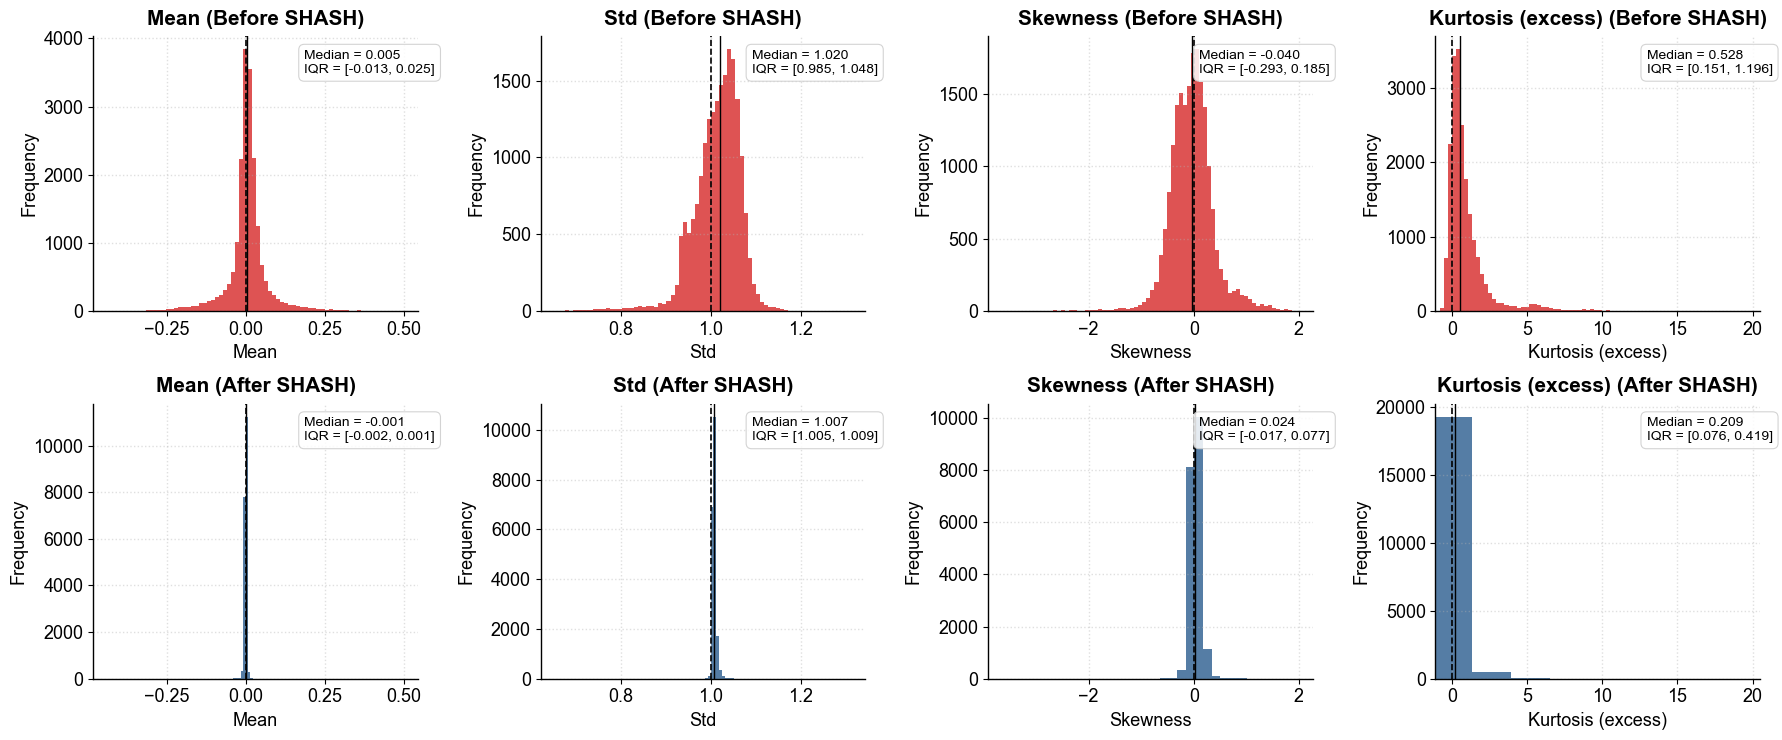

SHASH calibration, held-out CV, nested-holdout corrected (median [IQR]):
  Mean               ideal=+0.0   before=+0.0048 [-0.0127, +0.0250]   after=-0.0006 [-0.0023, +0.0007]
  Std                ideal=+1.0   before=+1.0203 [+0.9854, +1.0484]   after=+1.0065 [+1.0046, +1.0090]
  Skewness           ideal=+0.0   before=-0.0399 [-0.2926, +0.1848]   after=+0.0244 [-0.0169, +0.0771]
  Kurtosis (excess)  ideal=+0.0   before=+0.5282 [+0.1513, +1.1964]   after=+0.2088 [+0.0763, +0.4193]


In [23]:
cv2 = cv.merge(shn[['gene', 'ins_mean', 'ins_std', 'ins_skew', 'ins_kurt',
                    'nested_mean', 'nested_std', 'nested_skew', 'nested_kurt']], on='gene', how='left')

metrics = [
    ('Mean', 'mean_z', 'nested_mean', 0.0),
    ('Std', 'std_z', 'nested_std', 1.0),
    ('Skewness', 'cv_raw_skew', 'nested_skew', 0.0),
    ('Kurtosis (excess)', 'cv_raw_kurtosis', 'nested_kurt', 0.0)
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))

for col, (lab, raw_c, corr_c, ideal) in enumerate(metrics):
    xlim = cv2[raw_c].dropna().quantile([0, 1]).values  # before-SHASH range, shared with after-SHASH panel
    rows_info = [
        (raw_c, f'{lab} (Before SHASH)', '#d62828'),
        (corr_c, f'{lab} (After SHASH)', '#2b5c8f')
    ]
    
    for row, (c, title, color) in enumerate(rows_info):
        ax = axes[row, col]
        v = cv2[c].dropna()
        
        ax.hist(v, bins=80, color=color, edgecolor='none', alpha=0.8)
        ax.axvline(ideal, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(v.median(), color='black', linewidth=1.0)
        ax.set_xlim(xlim)
        
        ax.set_title(title, fontweight='bold', pad=8)
        ax.set_xlabel(lab)
        ax.set_ylabel('Frequency')
        
        med = v.median()
        q25 = v.quantile(0.25)
        q75 = v.quantile(0.75)
        stats_text = f"Median = {med:.3f}\nIQR = [{q25:.3f}, {q75:.3f}]"
        bbox_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc', linewidth=0.8)
        
        ax.text(0.65, 0.95, stats_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_props)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(FIG / 'cv_shash_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print('SHASH calibration, held-out CV, nested-holdout corrected (median [IQR]):')
for lab, raw_c, corr_c, ideal in metrics:
    r, c = cv2[raw_c].dropna(), cv2[corr_c].dropna()
    print(f'  {lab:18s} ideal={ideal:+.1f}   before={r.median():+.4f} [{r.quantile(.25):+.4f}, {r.quantile(.75):+.4f}]'
          f'   after={c.median():+.4f} [{c.quantile(.25):+.4f}, {c.quantile(.75):+.4f}]')

In [ ]:
CAT_LABELS = ['0 (Best)', '1', '2', '3', '4', '5+']

def categorize(s):
    return pd.cut(s.clip(upper=5), bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=CAT_LABELS)

print('genes with >=1 BH outlier -- raw vs per-fold(production) vs nested-holdout SHASH:')
for q in Q_LEVELS:
    qtag = f'q{int(q * 100):02d}'
    n_raw = (shn[f'raw_n_out_{qtag}'] > 0).sum()
    n_ins = (shn[f'ins_n_out_{qtag}'] > 0).sum()
    n_nest = (shn[f'nested_n_out_{qtag}'] > 0).sum()
    print(f'  q={q:.2f}: genes flagged raw={n_raw} ({n_raw/len(shn):.4f})  '
         f'per-fold={n_ins} ({n_ins/len(shn):.4f})  nested={n_nest} ({n_nest/len(shn):.4f})'
         f'  | total outlier samples raw={shn[f"raw_n_out_{qtag}"].sum()}'
         f'  in-sample={shn[f"ins_n_out_{qtag}"].sum()}  nested={shn[f"nested_n_out_{qtag}"].sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(CAT_LABELS)); w = 0.26
for ax, q in zip(axes, Q_LEVELS):
    qtag = f'q{int(q * 100):02d}'
    n_raw = categorize(shn[f'raw_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    n_ins = categorize(shn[f'ins_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    n_nest = categorize(shn[f'nested_n_out_{qtag}']).value_counts().reindex(CAT_LABELS).values
    bars = [ax.bar(x + off, vals, w, color=c, edgecolor='black', label=lab)
           for off, vals, c, lab in [(-w, n_raw, '#ee5050', 'raw'),
                                     (0, n_ins, '#2f4966', 'SHASH (per-fold, production)'),
                                     (w, n_nest, '#81b29a', 'SHASH (nested holdout)')]]
    ax.set_yscale('log')
    for group in bars:
        for bar in group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h, f'{int(h)}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(CAT_LABELS)
    ax.set_xlabel('# held-out outlier samples per gene (5+ pooled)'); ax.set_ylabel('# genes (log)')
    ax.set_title(f'BH q={q:.2f}: outlier count per gene', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / 'cv_bh_outlier_raw_ins_nested.png', dpi=150, bbox_inches='tight'); plt.show()

/tmp/ipykernel_404848/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
/tmp/ipykernel_404848/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
/tmp/ipykernel_404848/1209972148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,


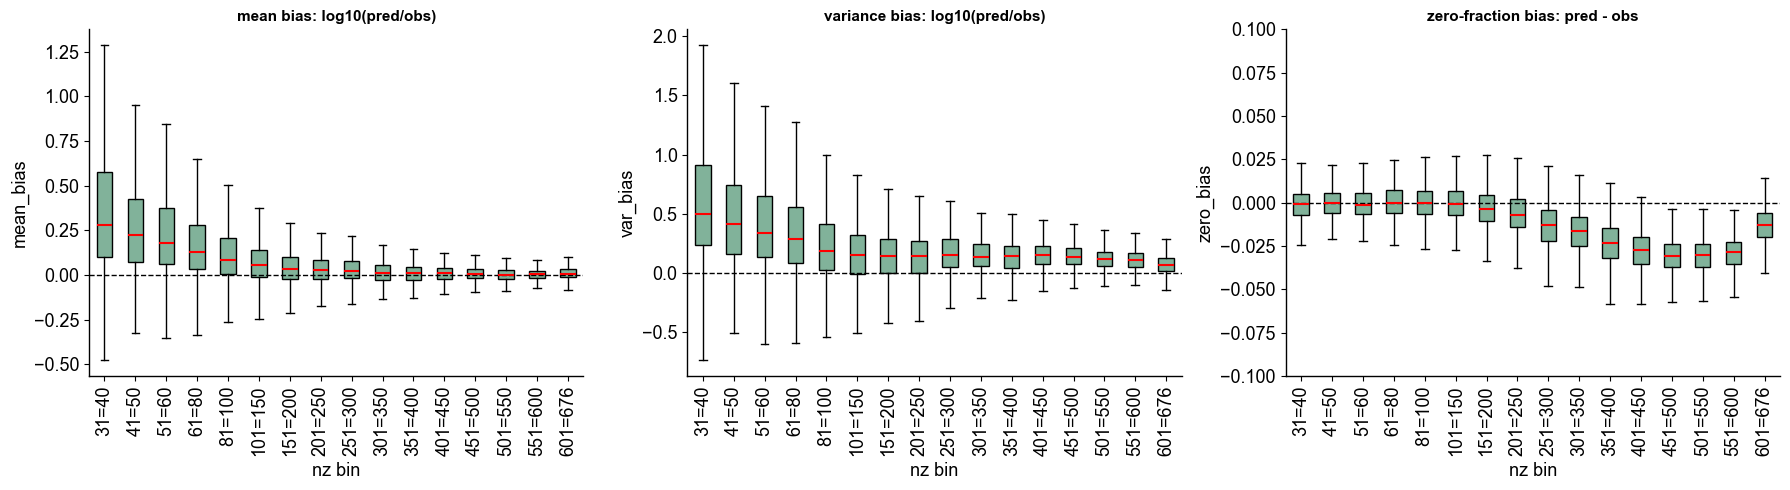

excluded (pool route, below first nz bin): 2060


,mean_bias,var_bias,zero_bias
nz_bin,,,
31=40,0.2785,0.5010,-0.0005
41=50,0.2212,0.4150,-0.0003
51=60,0.1770,0.3391,-0.0012
61=80,0.1316,0.2873,-0.0001
81=100,0.0830,0.1885,-0.0000
101=150,0.0574,0.1499,-0.0007
151=200,0.0344,0.1406,-0.0036
201=250,0.0272,0.1405,-0.0068
251=300,0.0240,0.1550,-0.0128


In [9]:
bias = pd.read_csv(CV / 'cv_calibration_moments.csv').merge(cv[['gene', 'nz', 'nz_bin']], on='gene', how='left')
bias['mean_bias'] = np.log10(np.maximum(bias.pred_mean, 1e-8) / np.maximum(bias.obs_mean, 1e-8))
bias['var_bias'] = np.log10(np.maximum(bias.pred_var, 1e-8) / np.maximum(bias.obs_var, 1e-8))
bias['zero_bias'] = bias.pred_zero - bias.obs_zero

bins_present = [b for b in NZ_LABELS if bias.nz_bin.eq(b).any()]
panels = [('mean_bias', 'mean bias: log10(pred/obs)'),
         ('var_bias', 'variance bias: log10(pred/obs)'),
         ('zero_bias', 'zero-fraction bias: pred - obs')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, panels):
    data = [bias.loc[bias.nz_bin == b, col].dropna().values for b in bins_present]
    ax.boxplot(data, labels=bins_present, patch_artist=True, showfliers=False,
              boxprops=dict(facecolor='#81b29a', color='black'),
              medianprops=dict(color='red', linewidth=1.5))
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('nz bin'); ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=90)
    if col == 'zero_bias':
        ax.set_ylim(-0.1, 0.1)
plt.tight_layout(); plt.savefig(FIG / 'cv_ppc_bias_vs_nz.png', dpi=150, bbox_inches='tight'); plt.show()

print(f'excluded (pool route, below first nz bin): {bias.nz_bin.isna().sum()}')
display(bias.groupby('nz_bin', observed=True)[['mean_bias', 'var_bias', 'zero_bias']].median().round(4))